<a href="https://colab.research.google.com/github/EgorMatveev26/MO_Attack/blob/main/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 3. Оптимизация, регуляризация и робастность нейросети

**Курс:** Машинное обучение. Безопасность ИИ-систем

**Формат:** индивидуально

**Среда:** Python, PyTorch

**По материалам Лекции 2.1 и Лекции 2.2**

## Цель работы
Экспериментально проверить, как выбор оптимизатора и методов регуляризации влияет на сходимость, переобучение, обобщение и чувствительность модели к возмущениям входа.

## Результаты обучения
После выполнения работы вы должны уметь:
- объяснять идею прямого прохода и backpropagation через цепное правило;
- различать SGD, Momentum и Adam с точки зрения траектории оптимизации и свойств найденного минимума;
- применять L2-регуляризацию, Dropout, BatchNorm и early stopping;
- оценивать train/test gap как признак переобучения;
- связывать переобучение и уязвимость модели к малым возмущениям входа.

## Как пользоваться этим ноутбуком
- Ячейки с `# TODO` необходимо заполнить самостоятельно.
- Ячейки с текстом **"Вопрос для отчёта"** требуют письменного ответа в markdown-ячейке ниже.
- Перед сдачей: Kernel → Restart & Run All, ноутбук должен выполняться от начала до конца без ошибок.


## 0. Подготовка окружения

In [ ]:
# TODO: импортируйте необходимые библиотеки
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## 1. Данные

**Задание:** загрузите датасет для классификации изображений.
Рекомендуется MNIST или Fashion-MNIST (через `torchvision.datasets`).


In [ ]:
# TODO: загрузите датасет (например, torchvision.datasets.MNIST)
# TODO: создайте train/val/test DataLoader-ы

from torchvision import datasets, transforms
# Превращаем картинку в тензор(массив чисел в диапозоне от 0 до 1) и нормализуем их(каждый элемент минус среднее яркостей всех пикселей
# обучающей выборки и делим все это на стандартное отклонение)
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
# Загружаем данные
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
# Разделим train на train(на них обучаем модель)/val(на них мы проверяем не переобучилась ли модель) (90%/10%)
val_size = int(0.1 * len(train_dataset))
train_size = len(train_dataset) - val_size
train_subset, val_subset = random_split(train_dataset, [train_size, val_size], generator=torch.Generator().manual_seed(RANDOM_STATE))
# Создаем DataLoader-ы(раскладываем данные на порции по 64 штуки и перемешиваем их чтобы модель не привыкала к порядку примеров)
train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)

val_loader   = DataLoader(val_subset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

print()
print("Размеры выборок:")
print(f"train: {len(train_subset)}")
print(f"val:   {len(val_subset)}")
print(f"test:  {len(test_dataset)}")
print()

print("Количество батчей в каждом лодере:")
print(f"train_loader: {len(train_loader)} батчей")
print(f"val_loader:   {len(val_loader)} батчей")
print(f"test_loader:  {len(test_loader)} батчей")



Размеры выборок:
train: 54000
val:   6000
test:  10000

Количество батчей в каждом лодере:
train_loader: 844 батчей
val_loader:   94 батчей
test_loader:  157 батчей


## 2. Формализм прямого прохода и backpropagation

**Задание:** опишите (в markdown, формулами) прямой проход для вашей архитектуры и кратко распишите, как вычисляется ошибка слоя \( \delta^{(l)} \) через цепное правило.

**Вопрос для отчёта:** почему backpropagation имеет вычислительную сложность \(O(P)\) по числу параметров, а не \(O(2P)\), как при наивном численном дифференцировании?


_Ваш ответ (формулы и объяснение):_


### Прямой проход

Для слоя $l$:

$$
z^{(l)} = W^{(l)} a^{(l-1)} + b^{(l)}, \qquad a^{(l)} = f(z^{(l)})
$$

Здесь $a^{(0)} = x$ — вход, $a^{(L)}$ — выход сети, $f$ — функция активации (ReLU в скрытых слоях).

Функция потерь — кросс-энтропия:

$$
L = -\sum_c y_c \log a_c^{(L)}
$$

### Backpropagation

Ошибка слоя: $\delta^{(l)} = \partial L / \partial z^{(l)}$.

**Выходной слой:**
$$
\delta^{(L)} = \nabla_{a^{(L)}} L \odot f'(z^{(L)})
$$

**Скрытые слои:**
$$
\delta^{(l)} = \left((W^{(l+1)})^T \delta^{(l+1)}\right) \odot f'(z^{(l)})
$$

**Градиенты параметров:**
$$
\frac{\partial L}{\partial W^{(l)}} = \delta^{(l)} (a^{(l-1)})^T, \qquad
\frac{\partial L}{\partial b^{(l)}} = \delta^{(l)}
$$

### Сложность

Backpropagation даёт градиенты всех параметров за **один** обратный проход, переиспользуя промежуточные $\delta^{(l)}$. Сложность — $O(P)$ по числу параметров.

Наивное численное дифференцирование требует двух прямых проходов **на каждый** параметр → $O(2P)$ проходов, что практически неприменимо.

Именно линейная сложность backprop делает обучение глубоких сетей возможным.

## 3. Базовая архитектура сети

In [ ]:
# TODO: определите класс простого MLP (2-3 полносвязных слоя)
# Параметризуйте модель так, чтобы можно было легко включать/выключать dropout и batchnorm

class SimpleMLP(nn.Module):
    # На входе картинка 28 на 28 соответственно всего 784 пикселя(то есть числа), 256 нейронов в скрытых слоях, 10 классов на выходе(логиты)
    # выключатели выключены и вероятность выключить нейрон 50%
    def __init__(self, input_dim=784, hidden_dim=256, num_classes=10, use_dropout=False, use_batchnorm=False, dropout_p=0.5):
        super().__init__()
        self.use_dropout = use_dropout
        self.use_batchnorm = use_batchnorm
        # 1 слой, на вход подаем массив из 784 чисел, сжимаем информацию и на выходе получаем 256 признаков
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # 2 слой, тут происходит комбинация выделенных признаков после первого слоя, на выходе также 256 признаков
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        # 3 слой, на вход подаем признаки после 2 слоя и получаем 10 логитов по одному на каждую цифру
        self.fc3 = nn.Linear(hidden_dim, num_classes)
        # если бачнорм включен(нормализация активаций-те данные, которые текут между слоями), то создаем для каждого скрытого слоя
        # отдельный бачнорм, чтобы среднее было 0, а отколение 1
        if use_batchnorm:
            self.bn1 = nn.BatchNorm1d(hidden_dim)
            self.bn2 = nn.BatchNorm1d(hidden_dim)
        # если дропаут включен, создаем слой дропаут, который будет выключать часть нейронов при обучении с вероятностью 50%
        if use_dropout:
            self.dropout = nn.Dropout(dropout_p)
        # функция активации(отрицательные значения заменяем на 0)
        self.relu = nn.ReLU()

    def forward(self, x):
        # Разворачиваем картинку в плоский вектор
        # берем номер картинки в батче, то есть 0 ось, -1 - перемножаем оси 1,2,3 - кол-во каналов, строки пикселей и столбцы пикселей
        x = x.view(x.size(0), -1)

        # 1 слой, линейное преобразование
        x = self.fc1(x)
        # если нормализация активаций включена, то нормализуем
        if self.use_batchnorm:
            x = self.bn1(x)
        # применяем функцию активации
        x = self.relu(x)
        # если дропаут включен, то выполняем это
        if self.use_dropout:
            x = self.dropout(x)
        # 2 слой
        x = self.fc2(x)
        if self.use_batchnorm:
            x = self.bn2(x)
        x = self.relu(x)
        if self.use_dropout:
            x = self.dropout(x)
        # Получаем 3 выходной слой из 10 логитов
        x = self.fc3(x)
        return x

In [ ]:
# TODO: напишите универсальные функции train_epoch(model, loader, optimizer, criterion, device)
# и evaluate(model, loader, criterion, device), возвращающие loss и accuracy
# Функция одной эпохи обучения
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    # суммарный loss(величина ошибки) по всем примерам, количество угаданных примеров моделью, общее кол-во примеров прошедших через модель
    total_loss, correct, total = 0.0, 0, 0
    # Отдаем модели батч картинок из обучающей выборки и батч правильных меток для этих картинок
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        # обнуляем градиенты перед новым шагом
        optimizer.zero_grad()
        # модель принимает батч, разворачивает его в плоский вектор, прогоняет через слои и отдает по 10 логитов на каждую картинку из батча
        logits = model(x)
        # возвращаем средний loss по батчу
        loss = criterion(logits, y)
        # считаем градиенты loss для каждого веса
        loss.backward()
        # обновляем веса
        optimizer.step()
        # накапливаем loss
        total_loss += loss.item() * x.size(0)
        # считаем правильные ответы
        correct += (logits.argmax(1) == y).sum().item()
        # считаем сколько всего примеров прошло
        total += x.size(0)
    # возвращаем средние метрики(средний loss и средний accuracy) за эпоху
    return total_loss / total, correct / total

# Функция, которая прогоняет модель по датасету без обучения и возвращает метрики
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total


## 4. Серия A. Сравнение оптимизаторов

**Задание:** обучите одну и ту же архитектуру (без дополнительной регуляризации) со следующими оптимизаторами:
- SGD;
- SGD + Momentum (momentum=0.9);
- Adam.

Для каждого варианта зафиксируйте одинаковое число эпох и одинаковый learning rate (или обоснуйте отличие).


In [ ]:
# TODO: обучите модель с оптимизатором SGD
# Сохраните историю train/test loss и accuracy по эпохам
torch.manual_seed(RANDOM_STATE)
# Создаем модель
model_sgd = SimpleMLP().to(device)
# Создаем оптимизатор(стохастический градиентный спуск) для обновления весов, передаем ему список всех обучаемых параметров(веса и смещения
# всех слоев), шаг обучения ставим 0.01
optimizer_sgd = optim.SGD(model_sgd.parameters(), lr=0.01)
# Создаем функцию потерь
criterion = nn.CrossEntropyLoss()

history_sgd = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}
EPOCHS = 10

for epoch in range(1, EPOCHS + 1):
    # Тут пошло уже обучение, прогоняем модель по всему train, обновляя веса
    tr_loss, tr_acc = train_epoch(model_sgd, train_loader, optimizer_sgd, criterion, device)
    # Прогоняем без обучения
    te_loss, te_acc = evaluate(model_sgd, test_loader, criterion, device)

    history_sgd["train_loss"].append(tr_loss)
    history_sgd["test_loss"].append(te_loss)
    history_sgd["train_acc"].append(tr_acc)
    history_sgd["test_acc"].append(te_acc)

    print(f"Epoch {epoch:02d} | "f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | "f"test_loss={te_loss:.4f} test_acc={te_acc:.4f}")


Epoch 01 | train_loss=0.8078 train_acc=0.8116 | test_loss=0.3392 test_acc=0.9031
Epoch 02 | train_loss=0.3109 train_acc=0.9106 | test_loss=0.2634 test_acc=0.9250
Epoch 03 | train_loss=0.2540 train_acc=0.9273 | test_loss=0.2291 test_acc=0.9338
Epoch 04 | train_loss=0.2174 train_acc=0.9375 | test_loss=0.1971 test_acc=0.9433
Epoch 05 | train_loss=0.1895 train_acc=0.9463 | test_loss=0.1767 test_acc=0.9467
Epoch 06 | train_loss=0.1676 train_acc=0.9516 | test_loss=0.1594 test_acc=0.9525
Epoch 07 | train_loss=0.1497 train_acc=0.9574 | test_loss=0.1465 test_acc=0.9575
Epoch 08 | train_loss=0.1346 train_acc=0.9617 | test_loss=0.1336 test_acc=0.9607
Epoch 09 | train_loss=0.1225 train_acc=0.9653 | test_loss=0.1257 test_acc=0.9625
Epoch 10 | train_loss=0.1117 train_acc=0.9682 | test_loss=0.1158 test_acc=0.9656


In [ ]:
# TODO: обучите модель с оптимизатором SGD + Momentum
torch.manual_seed(RANDOM_STATE)
# Создаем модель(стохастический спуск с импульсом)
model_mom = SimpleMLP().to(device)
# Создаем оптимизатор и передаем параметры
optimizer_mom = optim.SGD(model_mom.parameters(), lr=0.01, momentum=0.9)

history_sgd_momentum = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model_mom, train_loader, optimizer_mom, criterion, device)
    te_loss, te_acc = evaluate(model_mom, test_loader, criterion, device)

    history_sgd_momentum["train_loss"].append(tr_loss)
    history_sgd_momentum["test_loss"].append(te_loss)
    history_sgd_momentum["train_acc"].append(tr_acc)
    history_sgd_momentum["test_acc"].append(te_acc)

    print(f"Epoch {epoch:02d} | "f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | "f"test_loss={te_loss:.4f} test_acc={te_acc:.4f}")


Epoch 01 | train_loss=0.3172 train_acc=0.9081 | test_loss=0.1364 test_acc=0.9563
Epoch 02 | train_loss=0.1093 train_acc=0.9671 | test_loss=0.0920 test_acc=0.9697
Epoch 03 | train_loss=0.0705 train_acc=0.9784 | test_loss=0.0850 test_acc=0.9716
Epoch 04 | train_loss=0.0507 train_acc=0.9846 | test_loss=0.0743 test_acc=0.9775
Epoch 05 | train_loss=0.0376 train_acc=0.9886 | test_loss=0.0693 test_acc=0.9772
Epoch 06 | train_loss=0.0285 train_acc=0.9911 | test_loss=0.0695 test_acc=0.9793
Epoch 07 | train_loss=0.0195 train_acc=0.9946 | test_loss=0.0720 test_acc=0.9772
Epoch 08 | train_loss=0.0138 train_acc=0.9963 | test_loss=0.0706 test_acc=0.9796
Epoch 09 | train_loss=0.0109 train_acc=0.9974 | test_loss=0.0674 test_acc=0.9815
Epoch 10 | train_loss=0.0073 train_acc=0.9982 | test_loss=0.0663 test_acc=0.9807


In [ ]:
# TODO: обучите модель с оптимизатором Adam
torch.manual_seed(RANDOM_STATE)
model_adam = SimpleMLP().to(device)
optimizer_adam = optim.Adam(model_adam.parameters(), lr=1e-3)

history_adam = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model_adam, train_loader, optimizer_adam, criterion, device)
    te_loss, te_acc = evaluate(model_adam, test_loader, criterion, device)

    history_adam["train_loss"].append(tr_loss)
    history_adam["test_loss"].append(te_loss)
    history_adam["train_acc"].append(tr_acc)
    history_adam["test_acc"].append(te_acc)

    print(f"Epoch {epoch:02d} | "f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | "f"test_loss={te_loss:.4f} test_acc={te_acc:.4f}")


Epoch 01 | train_loss=0.2312 train_acc=0.9298 | test_loss=0.1132 test_acc=0.9637
Epoch 02 | train_loss=0.0953 train_acc=0.9710 | test_loss=0.0889 test_acc=0.9725
Epoch 03 | train_loss=0.0635 train_acc=0.9799 | test_loss=0.0787 test_acc=0.9763
Epoch 04 | train_loss=0.0471 train_acc=0.9847 | test_loss=0.0830 test_acc=0.9765
Epoch 05 | train_loss=0.0419 train_acc=0.9860 | test_loss=0.0824 test_acc=0.9779
Epoch 06 | train_loss=0.0343 train_acc=0.9886 | test_loss=0.0801 test_acc=0.9777
Epoch 07 | train_loss=0.0300 train_acc=0.9904 | test_loss=0.0943 test_acc=0.9756
Epoch 08 | train_loss=0.0255 train_acc=0.9918 | test_loss=0.0772 test_acc=0.9807
Epoch 09 | train_loss=0.0231 train_acc=0.9923 | test_loss=0.0800 test_acc=0.9802
Epoch 10 | train_loss=0.0207 train_acc=0.9932 | test_loss=0.0912 test_acc=0.9783


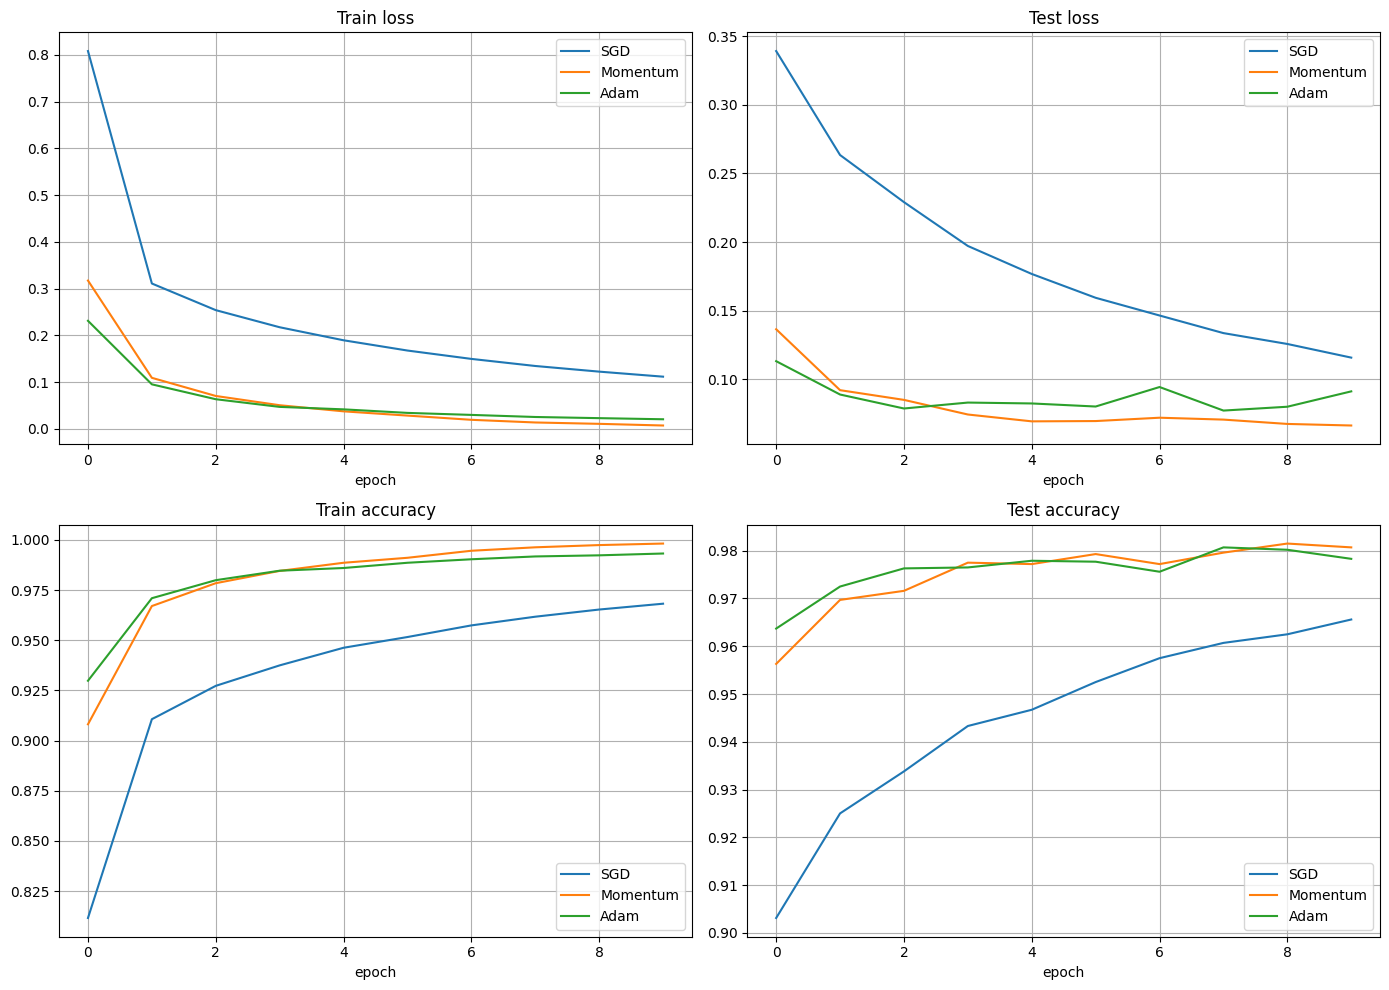

In [ ]:
# TODO: постройте графики train/test loss и train/test accuracy для всех трёх оптимизаторов
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss на train
axes[0, 0].plot(history_sgd["train_loss"],         label="SGD",      color="C0")
axes[0, 0].plot(history_sgd_momentum["train_loss"],label="Momentum", color="C1")
axes[0, 0].plot(history_adam["train_loss"],        label="Adam",     color="C2")
axes[0, 0].set_title("Train loss"); axes[0, 0].set_xlabel("epoch")
axes[0, 0].legend(); axes[0, 0].grid(True)

# Loss на test
axes[0, 1].plot(history_sgd["test_loss"],         label="SGD",      color="C0")
axes[0, 1].plot(history_sgd_momentum["test_loss"],label="Momentum", color="C1")
axes[0, 1].plot(history_adam["test_loss"],        label="Adam",     color="C2")
axes[0, 1].set_title("Test loss"); axes[0, 1].set_xlabel("epoch")
axes[0, 1].legend(); axes[0, 1].grid(True)

# Accuracy на train
axes[1, 0].plot(history_sgd["train_acc"],         label="SGD",      color="C0")
axes[1, 0].plot(history_sgd_momentum["train_acc"],label="Momentum", color="C1")
axes[1, 0].plot(history_adam["train_acc"],        label="Adam",     color="C2")
axes[1, 0].set_title("Train accuracy"); axes[1, 0].set_xlabel("epoch")
axes[1, 0].legend(); axes[1, 0].grid(True)

# Accuracy на test
axes[1, 1].plot(history_sgd["test_acc"],         label="SGD",      color="C0")
axes[1, 1].plot(history_sgd_momentum["test_acc"],label="Momentum", color="C1")
axes[1, 1].plot(history_adam["test_acc"],        label="Adam",     color="C2")
axes[1, 1].set_title("Test accuracy"); axes[1, 1].set_xlabel("epoch")
axes[1, 1].legend(); axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

**Вопрос для отчёта:** какой оптимизатор сходится быстрее? У какого варианта наибольший train/test gap? Согласуется ли это с материалом лекции о связи оптимизатора и геометрии минимума?

_Ваш ответ:_

Быстрее всех сходится Adam. Уже с 1-й эпохи у него минимальный train loss. Momentum немного отстаёт на старте, но со 2 эпохи догоняет Adam. SGD сходится медленнее всех, к 10-й эпохе train loss ~ 0.11 против ~ 0.01–0.02 у остальных. Наибольший gap(разрыв между качеством модели на тренировочной и тестовой выборке) у Adam (train 0.9932, test 0.9783). С 4 эпохи его test loss начинает расти, а test accuracy с 6 проседать. Это признак переобучения. У Momentum gap чуть меньше (train 0.9982, test 0.9807). У SGD gap минимальный (train 0.9682, test 0.9656), но это следствие недоучивания. Adam тяготеет к острым минимумам (лучший train, но рост test loss переобучение), SGD с шумом к плоским (недоучивается, но без переобучения), Momentum (быстрая сходимость без роста test loss(метрика лишь слегка колеблетсявокруг стабильного уровня)). Поэтому да, согласуется с материалами лекции, что оптимизатор определяет не только скорость, но и геометрию минимума.

## 5. Серия B. Сравнение методов регуляризации

**Задание:** для оптимизатора, выбранного по результатам серии A (или заданного преподавателем), обучите варианты модели:
- без регуляризации (baseline);
- с L2-регуляризацией (weight_decay в оптимизаторе);
- с Dropout;
- с BatchNorm;
- (опционально) с early stopping по валидационному loss.


In [ ]:
# TODO: baseline без регуляризации
torch.manual_seed(RANDOM_STATE)
model_baseline = SimpleMLP().to(device)
optimizer_baseline = optim.Adam(model_baseline.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

history_baseline = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model_baseline, train_loader, optimizer_baseline, criterion, device)
    te_loss, te_acc = evaluate(model_baseline, test_loader, criterion, device)

    history_baseline["train_loss"].append(tr_loss)
    history_baseline["test_loss"].append(te_loss)
    history_baseline["train_acc"].append(tr_acc)
    history_baseline["test_acc"].append(te_acc)

    print(f"Epoch {epoch:02d} | "f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | "f"test_loss={te_loss:.4f} test_acc={te_acc:.4f}")


Epoch 01 | train_loss=0.2312 train_acc=0.9298 | test_loss=0.1132 test_acc=0.9637
Epoch 02 | train_loss=0.0953 train_acc=0.9710 | test_loss=0.0889 test_acc=0.9725
Epoch 03 | train_loss=0.0635 train_acc=0.9799 | test_loss=0.0787 test_acc=0.9763
Epoch 04 | train_loss=0.0471 train_acc=0.9847 | test_loss=0.0830 test_acc=0.9765
Epoch 05 | train_loss=0.0419 train_acc=0.9860 | test_loss=0.0824 test_acc=0.9779
Epoch 06 | train_loss=0.0343 train_acc=0.9886 | test_loss=0.0801 test_acc=0.9777
Epoch 07 | train_loss=0.0300 train_acc=0.9904 | test_loss=0.0943 test_acc=0.9756
Epoch 08 | train_loss=0.0255 train_acc=0.9918 | test_loss=0.0772 test_acc=0.9807
Epoch 09 | train_loss=0.0231 train_acc=0.9923 | test_loss=0.0800 test_acc=0.9802
Epoch 10 | train_loss=0.0207 train_acc=0.9932 | test_loss=0.0912 test_acc=0.9783


In [ ]:
# TODO: L2-регуляризация (weight_decay)
torch.manual_seed(RANDOM_STATE)
model_l2 = SimpleMLP().to(device)
optimizer_l2 = optim.Adam(model_l2.parameters(), lr=1e-3, weight_decay=1e-4) # добавляем параметр затухания весов 0.0001
criterion = nn.CrossEntropyLoss()

history_l2 = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model_l2, train_loader, optimizer_l2, criterion, device)
    te_loss, te_acc = evaluate(model_l2, test_loader, criterion, device)

    history_l2["train_loss"].append(tr_loss)
    history_l2["test_loss"].append(te_loss)
    history_l2["train_acc"].append(tr_acc)
    history_l2["test_acc"].append(te_acc)

    print(f"Epoch {epoch:02d} | "f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | "f"test_loss={te_loss:.4f} test_acc={te_acc:.4f}")


Epoch 01 | train_loss=0.2321 train_acc=0.9293 | test_loss=0.1214 test_acc=0.9590
Epoch 02 | train_loss=0.0957 train_acc=0.9699 | test_loss=0.0786 test_acc=0.9765
Epoch 03 | train_loss=0.0658 train_acc=0.9796 | test_loss=0.0769 test_acc=0.9780
Epoch 04 | train_loss=0.0520 train_acc=0.9832 | test_loss=0.0823 test_acc=0.9743
Epoch 05 | train_loss=0.0439 train_acc=0.9858 | test_loss=0.0739 test_acc=0.9776
Epoch 06 | train_loss=0.0394 train_acc=0.9871 | test_loss=0.0800 test_acc=0.9764
Epoch 07 | train_loss=0.0321 train_acc=0.9893 | test_loss=0.0902 test_acc=0.9755
Epoch 08 | train_loss=0.0315 train_acc=0.9894 | test_loss=0.0777 test_acc=0.9777
Epoch 09 | train_loss=0.0296 train_acc=0.9903 | test_loss=0.1020 test_acc=0.9714
Epoch 10 | train_loss=0.0257 train_acc=0.9918 | test_loss=0.0812 test_acc=0.9791


In [ ]:
# TODO: Dropout
torch.manual_seed(RANDOM_STATE)
model_dropout = SimpleMLP(use_dropout=True, dropout_p=0.5).to(device) # добавляем выключение части нейронов с вероятностью 50%
optimizer_dropout = optim.Adam(model_dropout.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

history_dropout = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model_dropout, train_loader, optimizer_dropout, criterion, device)
    te_loss, te_acc = evaluate(model_dropout, test_loader, criterion, device)

    history_dropout["train_loss"].append(tr_loss)
    history_dropout["test_loss"].append(te_loss)
    history_dropout["train_acc"].append(tr_acc)
    history_dropout["test_acc"].append(te_acc)

    print(f"Epoch {epoch:02d} | "f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | "f"test_loss={te_loss:.4f} test_acc={te_acc:.4f}")


Epoch 01 | train_loss=0.3904 train_acc=0.8788 | test_loss=0.1415 test_acc=0.9588
Epoch 02 | train_loss=0.2187 train_acc=0.9348 | test_loss=0.1186 test_acc=0.9636
Epoch 03 | train_loss=0.1857 train_acc=0.9443 | test_loss=0.1218 test_acc=0.9655
Epoch 04 | train_loss=0.1665 train_acc=0.9505 | test_loss=0.0921 test_acc=0.9727
Epoch 05 | train_loss=0.1535 train_acc=0.9539 | test_loss=0.0916 test_acc=0.9733
Epoch 06 | train_loss=0.1451 train_acc=0.9556 | test_loss=0.0841 test_acc=0.9768
Epoch 07 | train_loss=0.1393 train_acc=0.9583 | test_loss=0.0830 test_acc=0.9753
Epoch 08 | train_loss=0.1321 train_acc=0.9599 | test_loss=0.0855 test_acc=0.9758
Epoch 09 | train_loss=0.1275 train_acc=0.9615 | test_loss=0.0801 test_acc=0.9774
Epoch 10 | train_loss=0.1236 train_acc=0.9631 | test_loss=0.0767 test_acc=0.9783


In [ ]:
# TODO: BatchNorm
torch.manual_seed(RANDOM_STATE)
model_batchnorm = SimpleMLP(use_batchnorm=True).to(device) # добавляем нормализацию активаций-того что течет между слоями при обучении
optimizer_batchnorm = optim.Adam(model_batchnorm.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

history_batchnorm = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_epoch(model_batchnorm, train_loader, optimizer_batchnorm, criterion, device)
    te_loss, te_acc = evaluate(model_batchnorm, test_loader, criterion, device)

    history_batchnorm["train_loss"].append(tr_loss)
    history_batchnorm["test_loss"].append(te_loss)
    history_batchnorm["train_acc"].append(tr_acc)
    history_batchnorm["test_acc"].append(te_acc)

    print(f"Epoch {epoch:02d} | "f"train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} | "f"test_loss={te_loss:.4f} test_acc={te_acc:.4f}")


Epoch 01 | train_loss=0.1973 train_acc=0.9417 | test_loss=0.0854 test_acc=0.9731
Epoch 02 | train_loss=0.0830 train_acc=0.9743 | test_loss=0.0730 test_acc=0.9761
Epoch 03 | train_loss=0.0600 train_acc=0.9806 | test_loss=0.0713 test_acc=0.9782
Epoch 04 | train_loss=0.0437 train_acc=0.9855 | test_loss=0.0653 test_acc=0.9808
Epoch 05 | train_loss=0.0367 train_acc=0.9883 | test_loss=0.0683 test_acc=0.9788
Epoch 06 | train_loss=0.0314 train_acc=0.9897 | test_loss=0.0739 test_acc=0.9786
Epoch 07 | train_loss=0.0253 train_acc=0.9917 | test_loss=0.0720 test_acc=0.9793
Epoch 08 | train_loss=0.0211 train_acc=0.9926 | test_loss=0.0571 test_acc=0.9827
Epoch 09 | train_loss=0.0223 train_acc=0.9924 | test_loss=0.0662 test_acc=0.9816
Epoch 10 | train_loss=0.0177 train_acc=0.9941 | test_loss=0.0671 test_acc=0.9809


In [ ]:
# TODO: сведите результаты всех вариантов регуляризации в единую таблицу
import pandas as pd
rows = []
for name, h in [("baseline", history_baseline), ("L2", history_l2), ("dropout", history_dropout), ("batchnorm", history_batchnorm)]:
    tr = h["train_acc"][-1] # train accuracy на последней эпохе
    te = h["test_acc"][-1] # test accuracy на последней эпохе
    rows.append({
        "variant": name,
        "train_acc": round(tr, 4),
        "test_acc": round(te, 4),
        "gap": round(tr - te, 4),
    })

results_table = pd.DataFrame(rows)
results_table

,variant,train_acc,test_acc,gap
0,baseline,0.9932,0.9783,0.0149
1,L2,0.9918,0.9791,0.0127
2,dropout,0.9631,0.9783,-0.0152
3,batchnorm,0.9941,0.9809,0.0132


**Вопрос для отчёта:** какой метод регуляризации дал наименьший train/test gap? Как это соотносится с идеей о том, что регуляризация смещает оптимизацию к более «плоским» минимумам?

_Ваш ответ:_

Наименьший положительный gap у L2 (0.0127 против 0.0149 у baseline), BatchNorm рядом (0.0132). У Dropout gap отрицательный (−0.0152),так как на train нейроны выключены, а на test все работают, поэтому test выше train. L2, Dropout и BatchNorm смещают оптимизацию к плоским минимумам. В плоском минимуме малые изменения параметров не сильно увеличивают loss - модель лучше обобщает, gap уменьшается. В таблице это видно, что у L2 и BatchNorm gap меньше, чем у baseline. Механизмы разные (L2 сжимает веса, BatchNorm шумит через батч, Dropout ансамблирует подсети), результат один устойчивее модель, меньше разрыв.

## 6. Серия C. Проверка устойчивости к возмущениям входа

**Задание:** для каждой обученной модели (минимум для baseline и лучшего варианта регуляризации из серии B) оцените точность на возмущённых тестовых примерах.

Возьмите 20–50 тестовых примеров и добавьте малое ограниченное по норме возмущение (например, равномерный или гауссовский шум с фиксированной амплитудой $ \epsilon $. Сравните accuracy на чистых и возмущённых данных.


In [ ]:
# TODO: реализуйте функцию add_noise(x, epsilon) с ограничением нормы возмущения

def add_noise(x, epsilon=1.0):
    # Добавляет к батчу x гауссов шум, epsilon амплитуда возмущения
    noise = torch.randn_like(x) * epsilon
    noise = torch.clamp(noise, -epsilon, epsilon)
    return x + noise


In [ ]:
# TODO: рассчитайте accuracy на чистых и возмущённых примерах для baseline и лучшей регуляризованной модели
# Сведите результат в таблицу: variant | clean_accuracy | perturbed_accuracy | drop

EPS = 1.0          # амплитуда возмущения
N_SAMPLES = 500    # берём 500 тестовых примеров

@torch.no_grad()
def accuracy_perturbed(model, loader, device, epsilon=None, n_samples=N_SAMPLES):
    # Accuracy на первых n_samples примерах
    # если epsilon задан с шумом
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)

        take = n_samples - total# добираем до нужного числа
        x, y = x[:take], y[:take]

        if epsilon is not None: # возмущаем только если epsilon задан
            x = add_noise(x, epsilon=epsilon)

        pred = model(x).argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)

        if total >= n_samples:# набрали -выходим
            break

    return correct / total

# Считаем метрики для трёх моделей чистые, возмущённые иразница
rows = []
for name, model in [("baseline",  model_baseline),
                    ("dropout",   model_dropout),
                    ("batchnorm", model_batchnorm)]:
    clean = accuracy_perturbed(model, test_loader, device, epsilon=None)
    noisy = accuracy_perturbed(model, test_loader, device, epsilon=EPS)
    rows.append({
        "variant":            name,
        "clean_accuracy":     round(clean, 4),
        "perturbed_accuracy": round(noisy, 4),
        "drop":               round(clean - noisy, 4),
    })

robust_table = pd.DataFrame(rows)
robust_table


,variant,clean_accuracy,perturbed_accuracy,drop
0,baseline,0.972,0.958,0.014
1,dropout,0.976,0.968,0.008
2,batchnorm,0.982,0.952,0.030


**Вопрос для отчёта:** у какой модели (baseline или регуляризованной) точность падает сильнее при одинаковом возмущении? Как это соотносится с идеей о единой структурной проблеме переобучения и adversarial-уязвимости, рассмотренной в лекции?

_Ваш ответ:_

Сильнее всего падает BatchNorm (drop = 0.030), слабее всего - Dropout (drop = 0.008). BatchNorm был лучшим на чистых данных 0.982 и худшим на шумных 0.952. Это подтверждает идею лекции, что переобучение и adversarial-уязвимость - одна проблема.

## 7. Итоговый вывод

**Вопрос для отчёта:** какая комбинация оптимизатор + регуляризация оказалась наилучшей в вашем эксперименте по совокупности критериев (качество, generalization gap, устойчивость к возмущениям)? Обоснуйте ответ ссылками на полученные графики и таблицы.

_Ваш ответ:_

По совокупности критериев лучшей оказалась связка Adam + Dropout. Adam в серии A сходился быстрее всех, а Dropout в серии B дал наименьший разрыв между train и test и лучше всех выдержал шум в серии C (drop = 0.008 - самый маленький). BatchNorm на чистых данных был точнее, но на шуме потерял больше всех (drop = 0.030), поэтому по совокупности проиграл. L2 дал маленький gap, но ничем особенно не выделился.

---
Выполните **не менее двух** из следующих заданий. Оформите результаты в отдельных ячейках ниже.

### С1. Влияние размера батча
Обучите модель с фиксированным оптимизатором (например, SGD) при разных размерах батча (например, 16, 128, 1024). Сравните итоговый train/test gap и устойчивость к возмущениям. Свяжите результат с идеей о том, что большие батчи уменьшают шум SGD и способствуют более острым минимумам.

### С2. Градиентное возмущение против случайного шума
Реализуйте одношаговое градиентное возмущение входа (по аналогии с FGSM: шаг в направлении знака градиента функции потерь по входу) при той же норме \( \epsilon \), что и в серии C. Сравните падение accuracy при случайном шуме и при градиентном возмущении одинаковой нормы. Объясните, почему градиентное возмущение обычно эффективнее.

### С3. Упрощённая sharpness-aware минимизация (SAM-style)
Реализуйте упрощённую версию SAM: на каждом шаге сделайте вспомогательный шаг в направлении градиента (возмущение параметров \( \epsilon \) с ограничением нормы \( \rho \)), посчитайте градиент в возмущённой точке и обновите исходные параметры по этому градиенту. Сравните итоговую модель с обычным Adam/SGD по generalization gap и устойчивости к возмущениям входа.

### С4. Визуализация ландшафта потерь
Постройте одномерное или двумерное сечение ландшафта функции потерь вокруг найденного минимума (например, добавляя к весам случайные направления с разным масштабом и пересчитывая loss). Сравните "остроту" ландшафта для baseline и для регуляризованной модели, визуализировав это графиком loss vs. amplitude.


In [ ]:
# ДЛЯ СИЛЬНЫХ СТУДЕНТОВ
# TODO: реализуйте выбранные задания (С1-С4) здесь
# С2 (FGSM (градиентное возмущение) против случайного шума)

EPS = 1.0
N_SAMPLES = 500

def fgsm_perturb(model, x, y, criterion, epsilon):
    # Одношаговое градиентное возмущение входа (FGSM)
    x_adv = x.clone().detach().requires_grad_(True)
    logits = model(x_adv)
    loss = criterion(logits, y)
    model.zero_grad()
    loss.backward()
    with torch.no_grad():
        x_adv = x_adv + epsilon * x_adv.grad.sign()
    return x_adv.detach()


@torch.no_grad()
def accuracy_fgsm(model, loader, device, epsilon, n_samples=N_SAMPLES):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        take = n_samples - total
        x, y = x[:take], y[:take]

        with torch.enable_grad():
            x_adv = fgsm_perturb(model, x, y, criterion, epsilon)

        pred = model(x_adv).argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)
        if total >= n_samples:
            break
    return correct / total


# Сравнение чистые, случайный шум и FGSM
rows = []
for name, model in [("baseline",  model_baseline), ("dropout",   model_dropout)]:
    clean = accuracy_perturbed(model, test_loader, device, epsilon=None)
    rand  = accuracy_perturbed(model, test_loader, device, epsilon=EPS)
    fgsm  = accuracy_fgsm(model, test_loader, device, epsilon=EPS)

    rows.append({
        "variant": name,
        "clean": round(clean, 4),
        "random_noise": round(rand, 4),
        "fgsm": round(fgsm, 4),
        "drop_random": round(clean - rand, 4),
        "drop_fgsm": round(clean - fgsm, 4),
    })

fgsm_table = pd.DataFrame(rows)
fgsm_table

,variant,clean,random_noise,fgsm,drop_random,drop_fgsm
0,baseline,0.972,0.958,0.034,0.014,0.938
1,dropout,0.976,0.966,0.038,0.010,0.938


При одинаковой амплитуде ε = 1.0 FGSM катастрофически эффективнее случайного шума, так как accuracy падает почти до случайной (с 0.96-0.97 до 0.03 у обеих моделей), тогда как гауссовский случайный шум сбивает её всего на 1–1.5%.

In [ ]:
# С1 (влияние размера батча)

from torch.utils.data import DataLoader

BATCH_SIZES = [16, 128, 1024]
EPOCHS = 10

# Берем оптимизатор SGD с momentum
def make_optimizer(model):
    return optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

histories = {} # сюда сложим истории для каждого batch_size
models = {} # сюда обученные модели

for bs in BATCH_SIZES:
    print(f"\nbatch_size = {bs}")

    # свой DataLoader под каждый размер батча
    train_loader_bs = DataLoader(train_dataset, batch_size=bs, shuffle=True)

    torch.manual_seed(RANDOM_STATE)
    model = SimpleMLP().to(device)
    optimizer = make_optimizer(model)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader_bs, optimizer, criterion, device)
        te_loss, te_acc = evaluate(model, test_loader, criterion, device)

        history["train_loss"].append(tr_loss)
        history["test_loss"].append(te_loss)
        history["train_acc"].append(tr_acc)
        history["test_acc"].append(te_acc)

        print(f"Epoch {epoch:02d} | "f"train_acc={tr_acc:.4f} | test_acc={te_acc:.4f} | gap={tr_acc - te_acc:+.4f}")

    histories[bs] = history
    models[bs] = model


batch_size = 16
Epoch 01 | train_acc=0.9357 | test_acc=0.9683 | gap=-0.0326
Epoch 02 | train_acc=0.9735 | test_acc=0.9697 | gap=+0.0038
Epoch 03 | train_acc=0.9815 | test_acc=0.9738 | gap=+0.0077
Epoch 04 | train_acc=0.9861 | test_acc=0.9738 | gap=+0.0123
Epoch 05 | train_acc=0.9886 | test_acc=0.9748 | gap=+0.0138
Epoch 06 | train_acc=0.9916 | test_acc=0.9791 | gap=+0.0125
Epoch 07 | train_acc=0.9933 | test_acc=0.9764 | gap=+0.0169
Epoch 08 | train_acc=0.9934 | test_acc=0.9769 | gap=+0.0165
Epoch 09 | train_acc=0.9934 | test_acc=0.9798 | gap=+0.0136
Epoch 10 | train_acc=0.9965 | test_acc=0.9811 | gap=+0.0154

batch_size = 128
Epoch 01 | train_acc=0.8833 | test_acc=0.9466 | gap=-0.0633
Epoch 02 | train_acc=0.9561 | test_acc=0.9642 | gap=-0.0081
Epoch 03 | train_acc=0.9705 | test_acc=0.9723 | gap=-0.0019
Epoch 04 | train_acc=0.9774 | test_acc=0.9751 | gap=+0.0023
Epoch 05 | train_acc=0.9826 | test_acc=0.9766 | gap=+0.0060
Epoch 06 | train_acc=0.9871 | test_acc=0.9805 | gap=+0.0066
Epoch

In [ ]:
# Итоговые метрики
rows = []
for bs, h in histories.items():
    tr = h["train_acc"][-1]
    te = h["test_acc"][-1]
    rows.append({
        "batch_size": bs,
        "train_acc": round(tr, 4),
        "test_acc": round(te, 4),
        "gap": round(tr - te, 4),
    })

bs_table = pd.DataFrame(rows)
bs_table

,batch_size,train_acc,test_acc,gap
0,16,0.9965,0.9811,0.0154
1,128,0.9951,0.9816,0.0135
2,1024,0.9562,0.9549,0.0013


In [ ]:
# Устойчивость к случайному шуму
EPS = 1.0
N_SAMPLES = 500

rows = []
for bs, model in models.items():
    clean = accuracy_perturbed(model, test_loader, device, epsilon=None)
    noisy = accuracy_perturbed(model, test_loader, device, epsilon=EPS)
    rows.append({
        "batch_size": bs,
        "clean": round(clean, 4),
        "perturbed": round(noisy, 4),
        "drop": round(clean - noisy, 4),
    })

bs_robust = pd.DataFrame(rows)
bs_robust

,batch_size,clean,perturbed,drop
0,16,0.980,0.970,0.010
1,128,0.984,0.964,0.020
2,1024,0.956,0.934,0.022


Маленький батч даёт наилучшую устойчивость к шуму (drop = 0.010 против 0.020 при 128 и 0.022 при 1024). Но по gap сравнение некорректно, так как у батча 1024 он наименьший (0.0013) из-за недоучивания (train accuracy 0.9562), а не из-за хорошего обобщения. Для честного сравнения нужно увеличить шаг обучения пропорционально батчу или дать больше эпох.

---

## Требования к сдаче
- Ноутбук выполняется целиком без ошибок (Kernel → Restart & Run All).
- Все `# TODO` заполнены, все вопросы для отчёта содержат письменный ответ.
- Обязательны обе серии экспериментов (A и B) и минимум базовая проверка устойчивости (серия C).
